### SMS spam detection is automatically classifying incoming text messages as either ham (legitimate) or spam using machine learning and deep learning models, so that harmful, fraudulent or unwanted messages can be filtered before reaching the user. In this project, we will:

### 1)Load and clean an SMS spam dataset and encode labels into numeric form.
### 2) Prepare text statistics and a text vectorisation pipeline for deep learning models.
### 3)Build three TensorFlow models, i.e a dense embedding model, a Bi-LSTM model and a transfer-learning model using the Universal Sentence Encoder (USE).
### 4)Train all models with a shared helper pipeline and evaluate them on accuracy, precision, recall and F1-score.
### 5)Visualise model performance using bar and line plots to compare metrics.

# Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
import tensorflow_hub as hub 
from tensorflow.keras import layers

# Step 2: Load the Dataset

In [3]:
df = pd.read_csv("spam.csv",encoding = "latin-1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.shape    


(5572, 5)

In [5]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   v1          5572 non-null   object 
 1   v2          5572 non-null   object 
 2   Unnamed: 2  0 non-null      float64
 3   Unnamed: 3  0 non-null      float64
 4   Unnamed: 4  0 non-null      float64
dtypes: float64(3), object(2)
memory usage: 217.8+ KB


# Step 3: Clean the dataset and encode labels

In [8]:
# Drop the columns which are empty
df = df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'],axis = 1)

In [9]:
# rename  column names to meaningful ones
df = df.rename(columns = {"v1":"label","v2":"Text"})

In [10]:
# encode ham to 0 and ham to 1
df["label_enc"] = df["label"].map({"ham":0, "spam":1})

In [11]:
df.head()

,label,Text,label_enc
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


# Step 4: Split Data and convert to NumPy arrays

In [13]:
# 80 for training and 20 for testing
X_train,X_test,y_train,y_test = train_test_split(df["Text"],df["label_enc"],test_size = 0.2,random_state = 42)

In [14]:
# we convert into numpy array because of Faster computation
X_train_np = X_train.to_numpy()
X_test_np = X_test.to_numpy()
y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

# Step 5: Compute text Statistics for Vectorization

In [16]:
avg_words_len = round(sum([len(i.split())
                      for i in df['Text']]) / len(df['Text']))
total_words_length = len(set(" ".join(df['Text']).split()))

print(f"Data Loaded. Training samples: {len(X_train_np)}")
print(f"Average words per message: {avg_words_len}")
print(f"Approximate vocabulary size: {total_words_length}")

Data Loaded. Training samples: 4457
Average words per message: 16
Approximate vocabulary size: 15686


# Step 6: Helper functions for training and evaluation

In [18]:
def compile_and_fit(model, epochs=5):
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    history = model.fit(
        X_train_np,
        y_train_np,
        epochs=epochs,
        validation_data=(X_test_np, y_test_np)
    )
    return history

def get_metrics(model, X, y):
    y_preds = np.round(model.predict(X))
    return {
        'accuracy': accuracy_score(y, y_preds),
        'precision': precision_score(y, y_preds),
        'recall': recall_score(y, y_preds),
        'f1-score': f1_score(y, y_preds)
    }

# Step 7: Create the TextVectorization layer

In [20]:
from tensorflow.keras.layers import TextVectorization
text_vec = TextVectorization(
    max_tokens=total_words_length,
    standardize='lower_and_strip_punctuation',
    output_mode='int',
    output_sequence_length=avg_words_len
)
text_vec.adapt(X_train_np)

# Step 8: Model 1 – Dense embedding model (build and train)

In [22]:
input_layer = layers.Input(shape=(1,), dtype=tf.string)
x = text_vec(input_layer)
x = layers.Embedding(input_dim=total_words_length, output_dim=128)(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(32, activation='relu')(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)

model_1 = keras.Model(input_layer, output_layer, name="Dense_Model")
history_1 = compile_and_fit(model_1)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9015 - loss: 0.2945 - val_accuracy: 0.9587 - val_loss: 0.1535
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9771 - loss: 0.0949 - val_accuracy: 0.9767 - val_loss: 0.0822
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9892 - loss: 0.0443 - val_accuracy: 0.9785 - val_loss: 0.0796
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9935 - loss: 0.0257 - val_accuracy: 0.9785 - val_loss: 0.0642
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9969 - loss: 0.0173 - val_accuracy: 0.9785 - val_loss: 0.0633


# Step 9: Model 2 – Bidirectional LSTM model (build and train)

In [24]:
input_layer = layers.Input(shape=(1,), dtype=tf.string)
x = text_vec(input_layer)
x = layers.Embedding(input_dim=total_words_length, output_dim=128)(x)
x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
x = layers.Bidirectional(layers.LSTM(64))(x)
x = layers.Flatten()(x)
x = layers.Dropout(0.1)(x)
x = layers.Dense(32, activation='relu')(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)

model_2 = keras.Model(input_layer, output_layer, name="BiLSTM_Model")
history_2 = compile_and_fit(model_2)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.9484 - loss: 0.1753 - val_accuracy: 0.9704 - val_loss: 0.0885
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9886 - loss: 0.0405 - val_accuracy: 0.9758 - val_loss: 0.0771
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9973 - loss: 0.0135 - val_accuracy: 0.9803 - val_loss: 0.0879
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9987 - loss: 0.0046 - val_accuracy: 0.9776 - val_loss: 0.1006
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9998 - loss: 0.0011 - val_accuracy: 0.9830 - val_loss: 0.1165


# Step 10: Model 3 – Transfer learning with Universal Sentence Encoder (build and train)

In [26]:
use_layer = hub.KerasLayer(
    "https://tfhub.dev/google/universal-sentence-encoder/4",
    trainable=False,
    input_shape=[],
    dtype=tf.string,
    name='USE'
)
input_layer = layers.Input(shape=[], dtype=tf.string)
embedding = layers.Lambda(lambda x: use_layer(
    x), output_shape=(512,))(input_layer)
x = layers.Dense(64, activation='relu')(embedding)
x = layers.Dropout(0.2)(x)
output_layer = layers.Dense(1, activation='sigmoid')(x)
model_3 = keras.Model(input_layer, output_layer, name="USE_Model")
history_3 = compile_and_fit(model_3)

Epoch 1/5



140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9100 - loss: 0.3049 - val_accuracy: 0.9722 - val_loss: 0.1151
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9778 - loss: 0.0837 - val_accuracy: 0.9794 - val_loss: 0.0696
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9834 - loss: 0.0574 - val_accuracy: 0.9830 - val_loss: 0.0586
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9861 - loss: 0.0468 - val_accuracy: 0.9839 - val_loss: 0.0557
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9892 - loss: 0.0407 - val_accuracy: 0.9839 - val_loss: 0.0516


# Step 11: Collect performance metrics for all models 

In [28]:
results = {
    'Dense Embedding': get_metrics(model_1, X_test_np, y_test_np),
    'Bi-LSTM': get_metrics(model_2, X_test_np, y_test_np),
    'Transfer Learning (USE)': get_metrics(model_3, X_test_np, y_test_np)
}

results_df = pd.DataFrame(results).transpose()
print("Performance Table:")
print(results_df)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
Performance Table:
                         accuracy  precision    recall  f1-score
Dense Embedding          0.978475   0.956204  0.879195  0.916084
Bi-LSTM                  0.982960   0.977941  0.892617  0.933333
Transfer Learning (USE)  0.983857   0.958042  0.919463  0.938356


# Step 12: Visualize

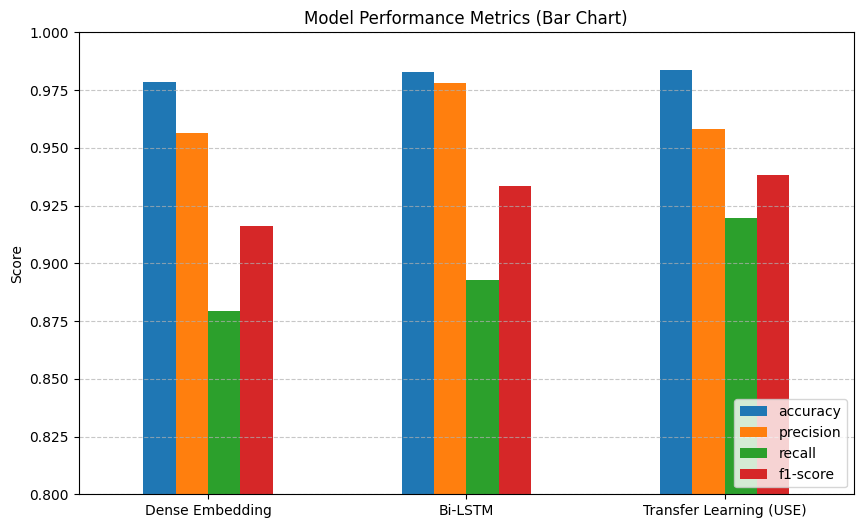

In [30]:
# a. Bar Chart
results_df.plot(kind='bar', figsize=(10, 6))
plt.title("Model Performance Metrics (Bar Chart)")
plt.ylabel("Score")
plt.ylim(0.8, 1.0)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

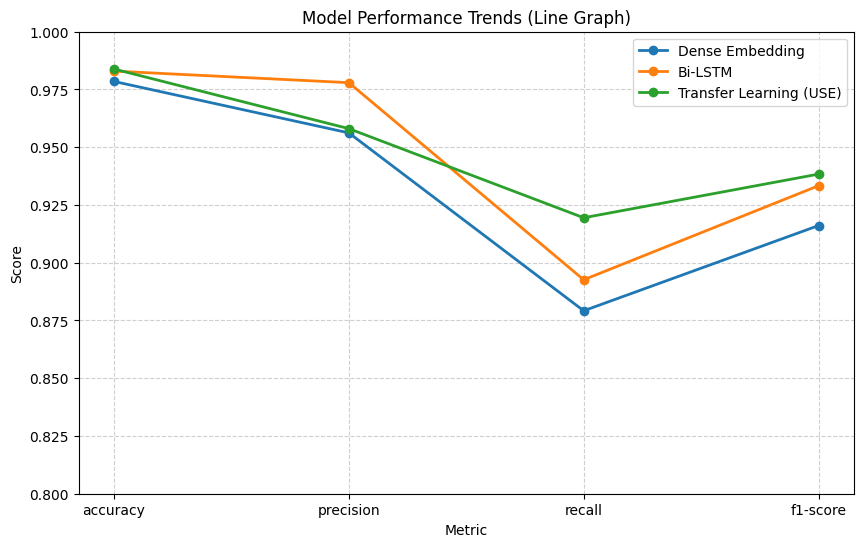

In [31]:
# b. Line Graph
plt.figure(figsize=(10, 6))

for model_name in results_df.index:
    plt.plot(
        results_df.columns,
        results_df.loc[model_name],
        marker='o',
        label=model_name,
        linewidth=2
    )
plt.title("Model Performance Trends (Line Graph)")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.ylim(0.8, 1.0)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


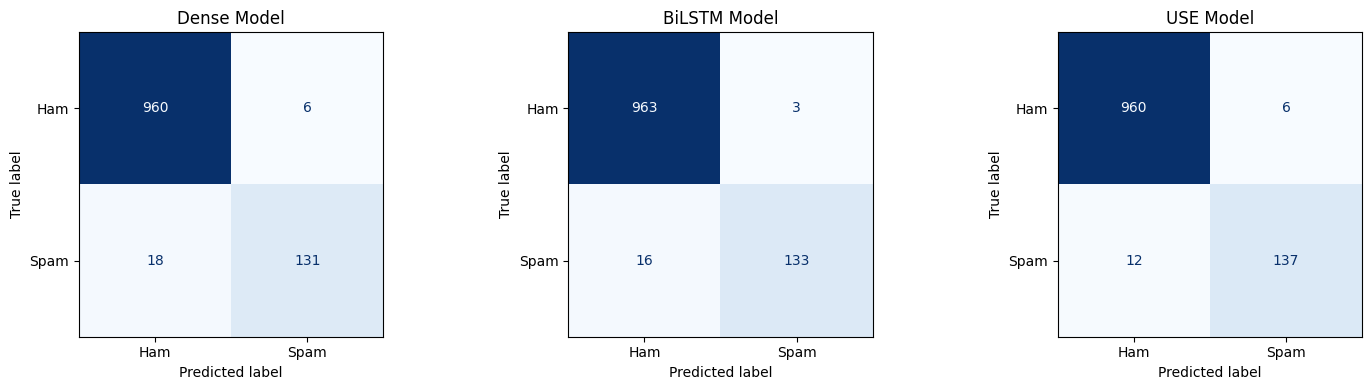

In [32]:
# confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = {
    "Dense Model": model_1,
    "BiLSTM Model": model_2,
    "USE Model": model_3
}

plt.figure(figsize=(15, 4))

for i, (name, model) in enumerate(models.items(), 1):
    y_pred = np.round(model.predict(X_test_np))
    cm = confusion_matrix(y_test_np, y_pred)

    plt.subplot(1, 3, i)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Ham", "Spam"])
    disp.plot(cmap='Blues', ax=plt.gca(), colorbar=False)
    plt.title(name)

plt.tight_layout()
plt.show()

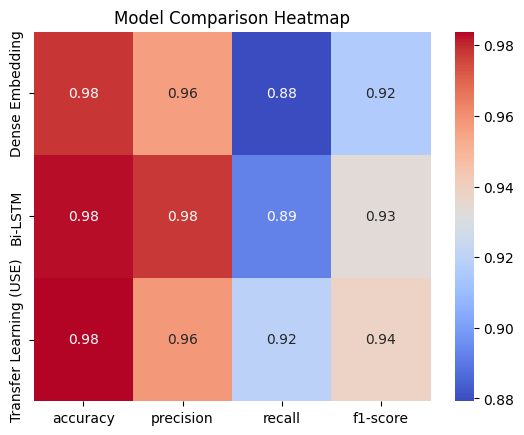

In [33]:
#heatmap
sns.heatmap(results_df, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Model Comparison Heatmap")
plt.show()